###                AI_Impact_Students_Life_2026_Dataset

#### Introduction

This dataset captures detailed academic and behavioral data from a diverse group of university students across multiple majors. Each record represents a student’s profile and their interaction with AI tools, covering metrics relevant to academic performance, study efficiency, and career confidence.

The dataset includes variables such as age, major, primary AI tool used, daily task frequency, main usage case, GPA before and after AI adoption, weekly time saved, ethical concern levels, and career confidence scores. Most importantly, it allows us to measure the impact of AI usage on GPA improvement and study habits, serving as a proxy for academic outcomes.

The objective of analyzing this dataset is to uncover patterns and factors contributing to how AI tools influence student life. By understanding correlations between tool choice, frequency of use, time saved, ethical concerns, and academic results, this analysis aims to support more effective and responsible integration of AI into education.

#### Import the necessary libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#### Import dataset

In [3]:
df=pd.read_csv(r"C:\Users\Jishna\OneDrive\Documents\DataScience\Projects\PROJECT_1\AI_Impact_Student_Life_2026.csv")

#### Display the first 5 rows of the dataset

In [4]:
print(df.head(5))

  Student_ID  Age                 Major Primary_AI_Tool  Task_Frequency_Daily  \
0   STU-6019   23  Software Engineering      Gemini Pro                     1   
1   STU-6962   22        Modern History  GitHub Copilot                     3   
2   STU-2338   18          Data Science      Perplexity                     2   
3   STU-1380   19               Biology      Claude 3.5                     5   
4   STU-1837   19               Biology      ChatGPT-4o                    10   

     Main_Usage_Case  GPA_Baseline  GPA_Post_AI  Time_Saved_Hours_Weekly  \
0     Code Debugging          2.62         2.62                        9   
1     Essay Drafting          3.99         4.00                        7   
2  Literature Review          2.57         2.57                       15   
3     Essay Drafting          2.67         2.87                       12   
4     Code Debugging          3.65         3.85                        5   

  AI_Ethics_Concern  Career_Confidence_Score  
0        

#### Display the last 5 rows of the dataset

In [5]:
print(df.tail(5))

     Student_ID  Age                 Major Primary_AI_Tool  \
1495   STU-2711   21        Modern History  GitHub Copilot   
1496   STU-4888   21               Biology  GitHub Copilot   
1497   STU-0180   23  Software Engineering  GitHub Copilot   
1498   STU-4392   23             Fine Arts      Perplexity   
1499   STU-4702   23          Data Science      Gemini Pro   

      Task_Frequency_Daily Main_Usage_Case  GPA_Baseline  GPA_Post_AI  \
1495                     4   Brainstorming          3.35         3.55   
1496                     3  Essay Drafting          3.59         3.89   
1497                     8  Code Debugging          3.20         3.40   
1498                     6   Brainstorming          3.99         4.00   
1499                     4       Exam Prep          3.53         3.43   

      Time_Saved_Hours_Weekly AI_Ethics_Concern  Career_Confidence_Score  
1495                        7            Medium                        7  
1496                       13         

#### Data Cleaning

In [6]:
# Check whether there are any missing values
print(df.isnull().sum())

Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64


In [7]:
# Check for duplicate rows
print(df.duplicated().sum())

0


In [8]:
# Remove spaces from the column data
def remove_spaces(df,columns):
    for col in columns:
        df[col]=df[col].astype(str).str.strip().str.replace(" ", "_")
    return df

df=remove_spaces(df,["Major","Primary_AI_Tool","Main_Usage_Case"])
for col in ["Major","Primary_AI_Tool","Main_Usage_Case"]:
    print("\n",col,":",df[col].unique())


 Major : ['Software_Engineering' 'Modern_History' 'Data_Science' 'Biology'
 'Business_Administration' 'Fine_Arts']

 Primary_AI_Tool : ['Gemini_Pro' 'GitHub_Copilot' 'Perplexity' 'Claude_3.5' 'ChatGPT-4o']

 Main_Usage_Case : ['Code_Debugging' 'Essay_Drafting' 'Literature_Review' 'Exam_Prep'
 'Brainstorming']


### Outlier Detection

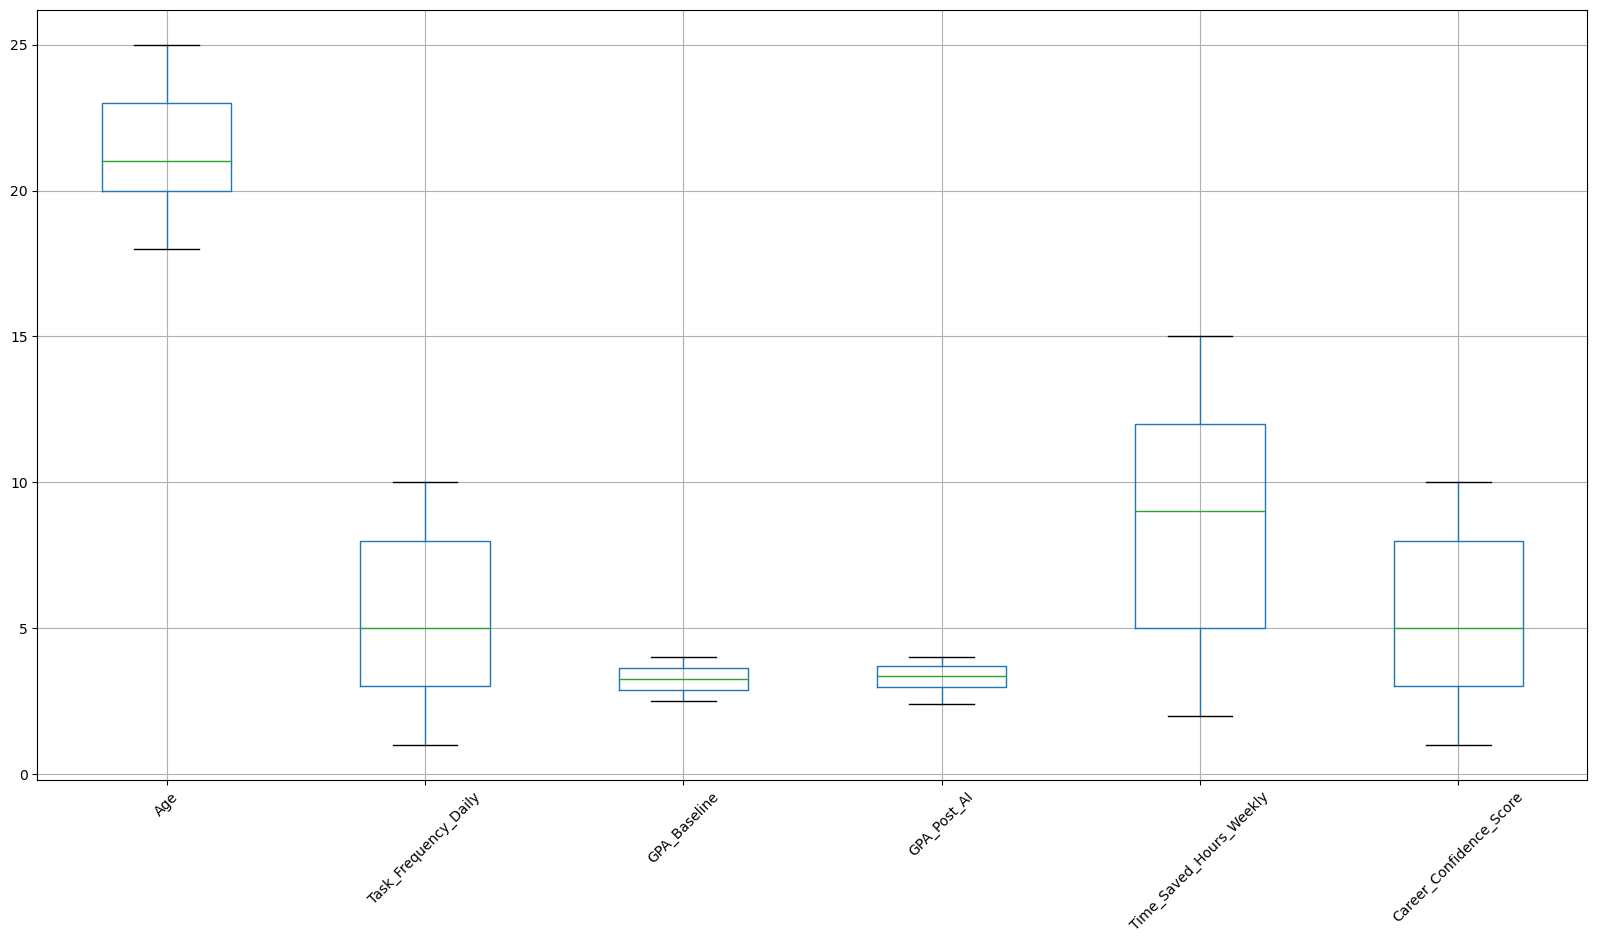

In [9]:
# plot boxplot for checking outliers
df.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()

### Standardize categorical values

In [10]:
#checking column name start with title cases and alphanumeric


def check_title(col):
    count = 0
    for i in col:
        if isinstance(i, str) and i.istitle():
            count += 1
    print("Title Case Count =", count)


def check_alnum(col):
    count = 0
    for i in col:
        if isinstance(i, str) and i.isalnum():
            count += 1
    print("Alphanumeric Count =", count)




In [11]:
#Applying title function for checking
check_title(df['Major'])
check_title(df['AI_Ethics_Concern'])
check_title(df['Primary_AI_Tool'])
check_title(df['Main_Usage_Case'])


Title Case Count = 1500
Title Case Count = 1500
Title Case Count = 901
Title Case Count = 1500


In [12]:
#Applying alphanumeric function for checking
check_alnum(df['Major'])
check_alnum(df['AI_Ethics_Concern'])
check_alnum(df['Primary_AI_Tool'])
check_alnum(df['Main_Usage_Case'])


Alphanumeric Count = 259
Alphanumeric Count = 1500
Alphanumeric Count = 302
Alphanumeric Count = 286


In [13]:
def make_title(col):
    return col.astype(str).str.strip().str.title()


df['Primary_AI_Tool']=make_title(df['Primary_AI_Tool'])
check_title(df['Primary_AI_Tool'])

Title Case Count = 1500


In [14]:
def make_alnum(col):
    return col.astype(str).str.strip().str.replace(r'[^A-Za-z0-9]', '', regex=True)

df['Primary_AI_Tool']=make_alnum(df['Primary_AI_Tool'])
check_alnum(df['Primary_AI_Tool'])

df['Major']=make_alnum(df['Major'])
check_alnum(df['Major'])

df['Main_Usage_Case']=make_alnum(df['Main_Usage_Case'])
check_alnum(df['Main_Usage_Case'])

Alphanumeric Count = 1500
Alphanumeric Count = 1500
Alphanumeric Count = 1500


#### Data Understanding

In [15]:
# size of the dataset
df.shape

(1500, 11)

In [16]:
# Basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB
None


In [17]:
# Use summary statistics to understand distributions.
print(df.describe())


               Age  Task_Frequency_Daily  GPA_Baseline  GPA_Post_AI  \
count  1500.000000           1500.000000   1500.000000  1500.000000   
mean     21.494000              5.407333      3.256853     3.344587   
std       2.297277              2.905462      0.430583     0.437409   
min      18.000000              1.000000      2.500000     2.400000   
25%      20.000000              3.000000      2.880000     2.980000   
50%      21.000000              5.000000      3.260000     3.360000   
75%      23.000000              8.000000      3.620000     3.710000   
max      25.000000             10.000000      4.000000     4.000000   

       Time_Saved_Hours_Weekly  Career_Confidence_Score  
count               1500.00000              1500.000000  
mean                   8.51000                 5.417333  
std                    4.07148                 2.844977  
min                    2.00000                 1.000000  
25%                    5.00000                 3.000000  
50%         

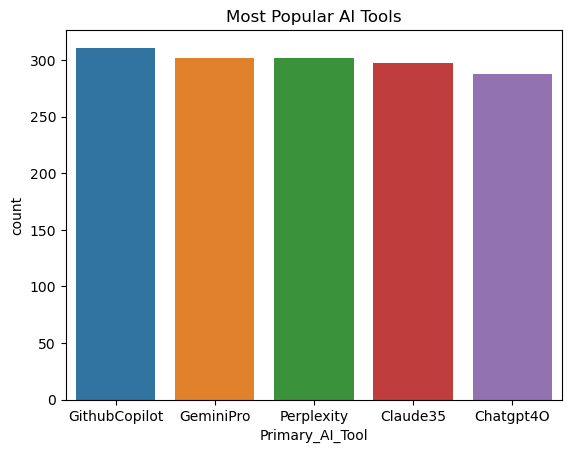

In [18]:
# 1) Which AI tool most popular among Students?

sns.countplot(x="Primary_AI_Tool",data=df,order=df["Primary_AI_Tool"].value_counts().index)
plt.title("Most Popular AI Tools")
plt.show()


In [19]:
# 2) What is the average GPA improvement across all students?

df["GPA_Change"]=df["GPA_Post_AI"]-df["GPA_Baseline"]
Average=df["GPA_Change"].mean()
print(" Average GPA improvement=",Average)

 Average GPA improvement= 0.08773333333333334


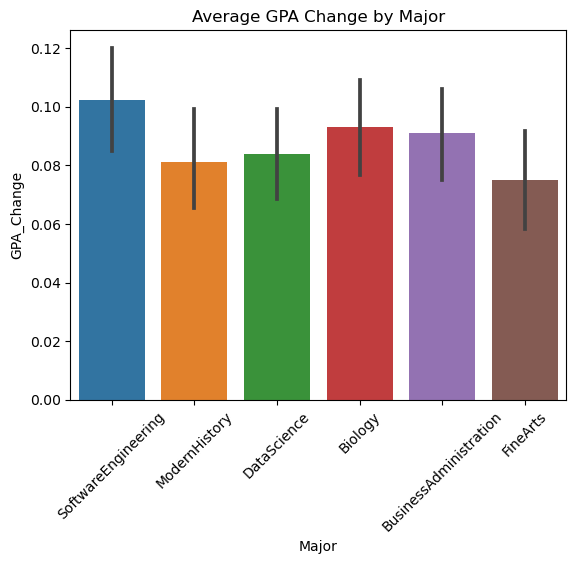

In [ ]:
# 3) Which major shows the highest GPA improvement?

sns.barplot(x="Major",y="GPA_Change",data=df,estimator="mean")
plt.title("Average GPA Change by Major")
plt.xticks(rotation=45)
plt.show()


   

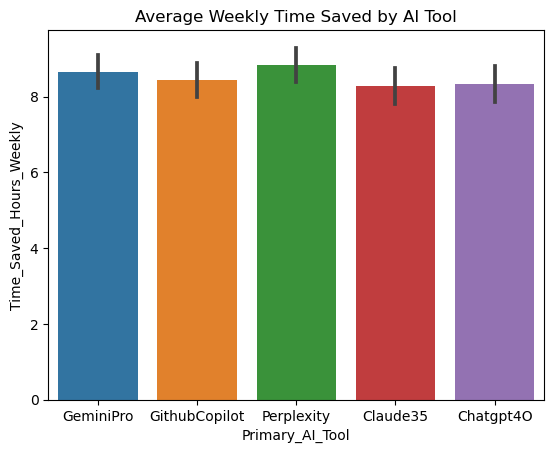

In [21]:
# 4) Which AI tool saves the most time weekly?

sns.barplot(x="Primary_AI_Tool",y="Time_Saved_Hours_Weekly",data=df,estimator="mean")
plt.title("Average Weekly Time Saved by AI Tool")
plt.show()



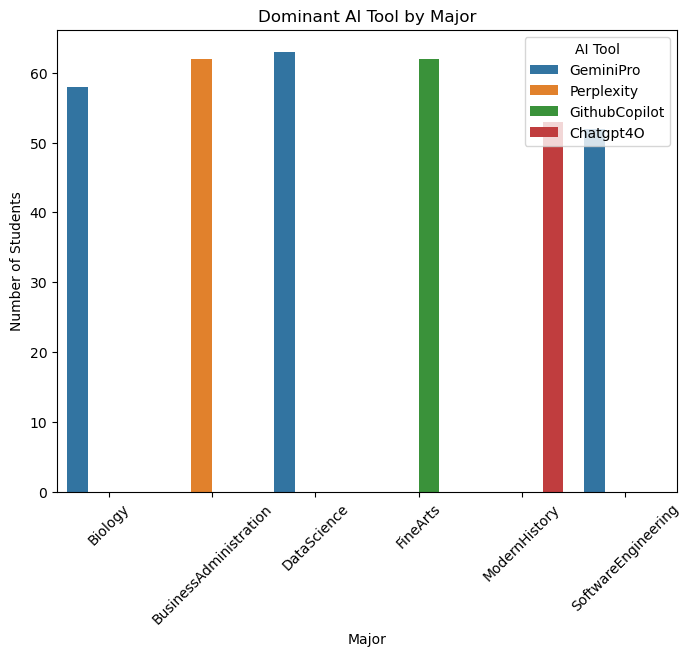

In [22]:
# 5) Which majors rely most heavily on a single AI tool (dominance analysis)?

tool_major=df.groupby(["Major","Primary_AI_Tool"]).size().reset_index(name="Count")
result=tool_major.loc[tool_major.groupby("Major")["Count"].idxmax()].reset_index(drop=True)

plt.figure(figsize=(8,6))
sns.barplot(x="Major",y="Count",hue="Primary_AI_Tool",data=result)
plt.title("Dominant AI Tool by Major")
plt.ylabel("Number of Students")
plt.xlabel("Major")
plt.xticks(rotation=45)
plt.legend(title="AI Tool")
plt.show()



C:\Users\Jishna\AppData\Local\Temp\ipykernel_17220\2032436191.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df,x="Task_Frequency_Daily",y="GPA_Change",estimator="mean",ci="sd")


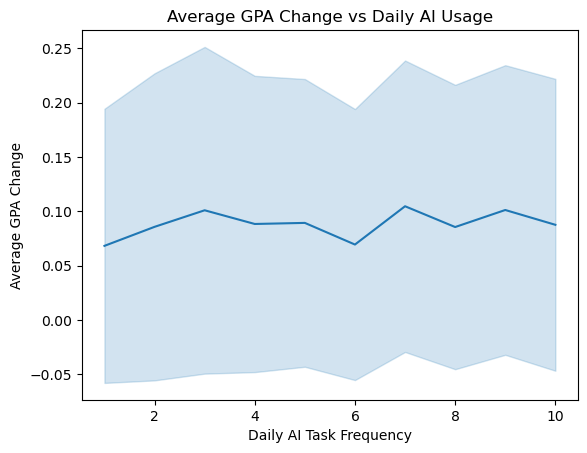

In [23]:
# 6) Does frequent AI usage improve GPA?

sns.lineplot(data=df,x="Task_Frequency_Daily",y="GPA_Change",estimator="mean",ci="sd")
plt.title("Average GPA Change vs Daily AI Usage")
plt.xlabel("Daily AI Task Frequency")
plt.ylabel("Average GPA Change")
plt.show() 

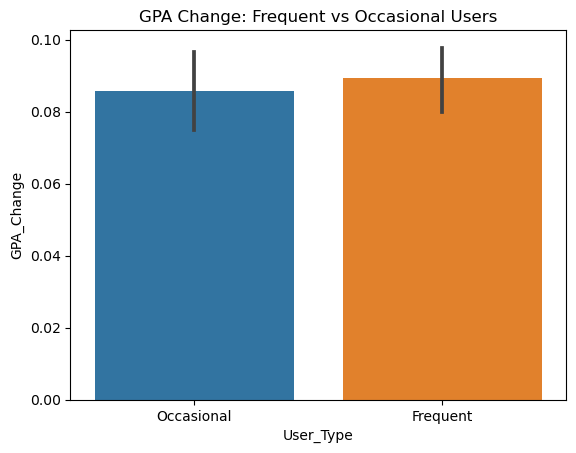

In [24]:
# 7)  Do frequent users (≥5 tasks daily) improve more than occasional users?

df["User_Type"]=["Frequent" if x>=5 else "Occasional" for x in df["Task_Frequency_Daily"]]
sns.barplot(x="User_Type",y="GPA_Change",data=df)
plt.title("GPA Change: Frequent vs Occasional Users")
plt.show()


In [25]:
# 8) Which AI tool is most consistent (least variance in GPA outcomes)?

df.groupby("Primary_AI_Tool")["GPA_Change"].std().sort_values()



Primary_AI_Tool
Claude35         0.129023
Perplexity       0.133954
Chatgpt4O        0.134537
GeminiPro        0.137160
GithubCopilot    0.139256
Name: GPA_Change, dtype: float64

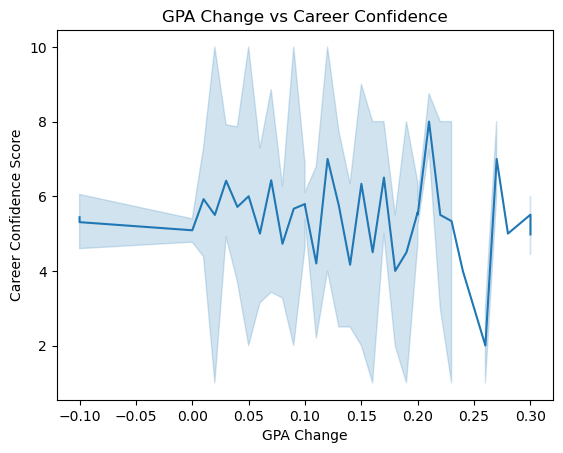

In [26]:
# 9) Is career confidence correlated with GPA improvement?

sns.lineplot(x="GPA_Change",y="Career_Confidence_Score",data=df)
plt.title("GPA Change vs Career Confidence")
plt.xlabel("GPA Change")
plt.ylabel("Career Confidence Score")
plt.show()

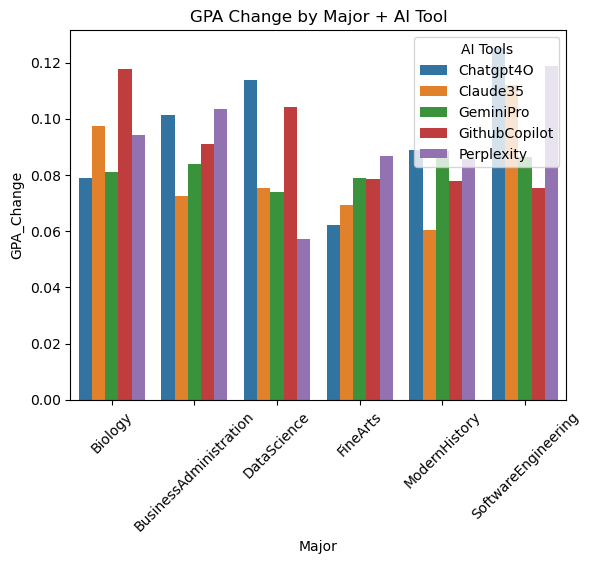

In [27]:
# 10) Which Major + AI Tool combination yields the best GPA improvement?

combo=df.groupby(["Major","Primary_AI_Tool"])["GPA_Change"].mean().reset_index()
sns.barplot(x="Major",y="GPA_Change",hue="Primary_AI_Tool",data=combo)
plt.title("GPA Change by Major + AI Tool")
plt.xticks(rotation=45)
plt.legend(title="AI Tools",loc="upper right")
plt.show()

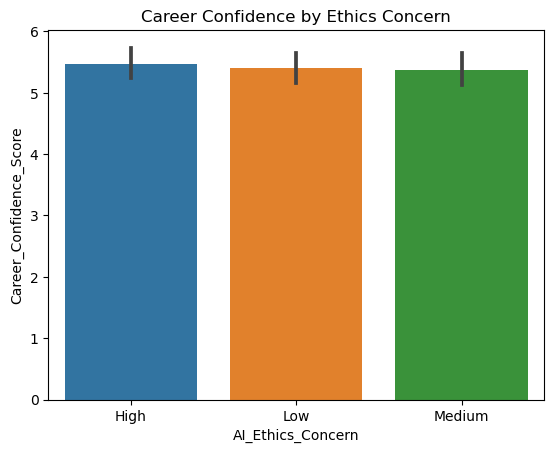

In [28]:
# 11) Which ethics group reports the highest career confidence?

order=(df.groupby("AI_Ethics_Concern")["Career_Confidence_Score"].mean().sort_values(ascending=False).index)
sns.barplot(x="AI_Ethics_Concern",y="Career_Confidence_Score",data=df,estimator="mean",order=order)
plt.title("Career Confidence by Ethics Concern")
plt.show()

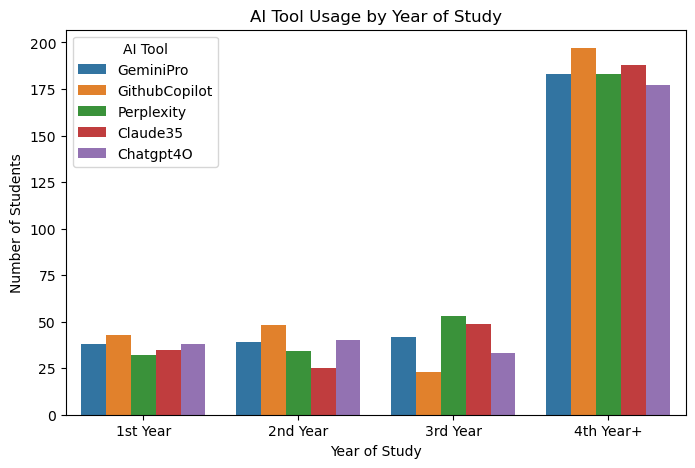

In [29]:
# 12) How does AI tool usage vary by year of study?

def map_year(age):
    if age==18:
        return "1st Year"
    elif age==19:
        return "2nd Year"
    elif age==20:
        return "3rd Year"
    else:
        return "4th Year+"

df["Year_of_Study"] = df["Age"].apply(map_year)


plt.figure(figsize=(8,5))
sns.countplot(x="Year_of_Study",hue="Primary_AI_Tool",data=df,order=["1st Year","2nd Year","3rd Year","4th Year+"])
plt.title("AI Tool Usage by Year of Study")
plt.xlabel("Year of Study")
plt.ylabel("Number of Students")
plt.legend(title="AI Tool")
plt.show()

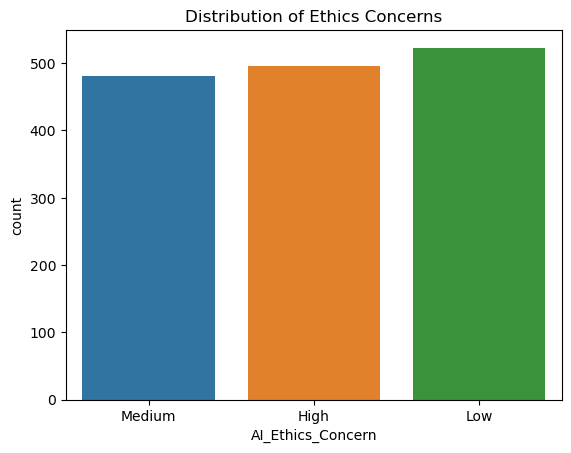

In [30]:
# 13) How are ethics concerns distributed among students?

sns.countplot(x="AI_Ethics_Concern",data=df)
plt.title("Distribution of Ethics Concerns")
plt.show()

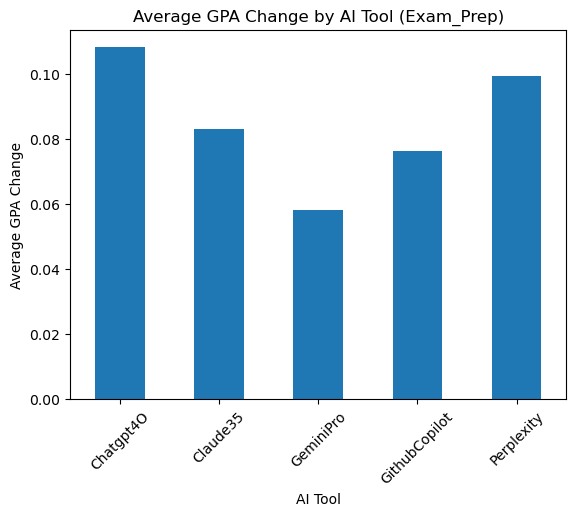

In [31]:
# 14)Which AI tool is most used for exam prep, and how effective is it?

exam=df[df['Main_Usage_Case']=='ExamPrep']
exam.groupby('Primary_AI_Tool')['GPA_Change'].mean().plot(kind='bar')
plt.title("Average GPA Change by AI Tool (Exam_Prep)")
plt.ylabel("Average GPA Change")
plt.xlabel("AI Tool")
plt.xticks(rotation=45)
plt.show()

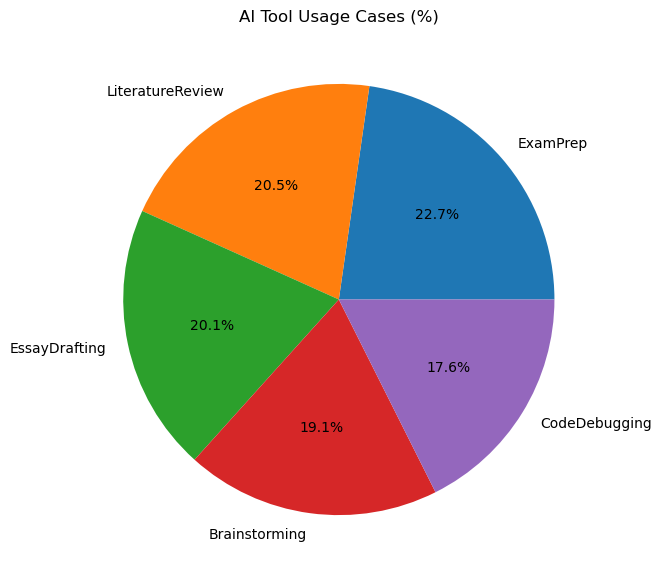

In [32]:
# 15) What percentage of students use AI tools for different academic tasks?

usage_counts=df['Main_Usage_Case'].value_counts(normalize=True)*100
usage_counts.plot(kind='pie',autopct='%1.1f%%',figsize=(7,7))
plt.title("AI Tool Usage Cases (%)")
plt.ylabel("")
plt.show()

### Suggestions & Recommendations

 1) Use AI tools as learning support, not shortcuts  
Encourage students to treat AI as a guide for understanding concepts rather than a way to bypass assignments.

2) Balance AI with self-study  
Promote combining AI assistance with independent effort to strengthen critical thinking and problem-solving skills.

3) Diversify AI tools  
Avoid reliance on a single platform; explore multiple AI tools to gain broader perspectives and better learning outcomes.

4) Students should use AI tools to improve understanding of difficult topics, which can help increase GPA over time.

5) Manage usage time  
Limit daily reliance on AI to prevent over-dependence and encourage independent learning habits.

6) Institutional support  
Universities and schools should introduce AI literacy programs and establish clear policies for academic use.